# Best-fit $z_{\mathrm{eff}}$ for L1_m9 CIB, and the $100/143\,\mathrm{GHz}$ MBB scaling

FLAMINGO / Yang et al. (2026) release **bandpass-convolved** CIB specific-intensity maps at
**$217$, $353$, $545$, $857\,\mathrm{GHz}$** only. Planck HFI also needs $100$ and $143\,\mathrm{GHz}$.
Those two channels sit **below** the lowest released band, so this repo does **not** interpolate:
it copies the $217\,\mathrm{GHz}$ spatial template and rescales every pixel by a single number — the
ratio of a three-parameter modified blackbody (MBB / greybody) evaluated at an effective redshift
$z_{\mathrm{eff}}$.

This notebook:

1. Writes down the SED used in `flamingo_mock.spectral` (Yang et al. 2026, eq. 12, §3.5.1).
2. Fits $z_{\mathrm{eff}}$ to the **released** L1_m9 intensity maps ($217$–$857\,\mathrm{GHz}$).
3. Shows the **pipeline** scaling that was actually applied to the on-disk $100$ and $143\,\mathrm{GHz}$
   maps, which uses the fixed convention $z_{\mathrm{eff}}=1.5$ from `config.CIB_Z_EFF`.

The fit and the shipped products need not agree. Yang's $(\beta_{\mathrm{d}},T_0,\alpha)$ were
constrained on Planck CIB $C_\ell$ (Lenz et al.), while a single-$z$ monochromatic greybody is only
an extrapolation kernel. L1_m9 lightcones also stop at $z=3$, versus $z=4.5$ for L2p8.


## 0. Setup

Activate `cmbagent_env` before running. Maps live on `/rds`; we `ud_grade` to a coarse $N_{\mathrm{side}}$
for sky means (the mean is preserved under `ud_grade`). Native products remain $N_{\mathrm{side}}=4096$.


In [1]:
from __future__ import annotations

import inspect
from pathlib import Path

import healpy as hp
import matplotlib.pyplot as plt
import numpy as np
from astropy.io import fits

from flamingo_mock.cib import approximate_cib_intensity
from flamingo_mock.config import CIB_ALPHA, CIB_BETA_D, CIB_T0, CIB_Z_EFF, T_CMB
from flamingo_mock.io import load_flamingo_map
from flamingo_mock.spectral import (
    dB_dT_Jy_per_sr_per_K,
    intensity_to_uK,
    sed_ratio,
    sed_shape_observed,
    tdust,
    theta_nu,
)

CIB_DIR = Path("/rds/rds-lxu/flamingo/integrated_maps_synthetic/components/cib/L1_m9")
RELEASED = (217, 353, 545, 857)
PLANCK = (100, 143, 217, 353, 545, 857)
NSIDE_FIT = 64  # sky mean is unbiased; full Nside=4096 is ~800 MB per map

print("CIB_DIR:", CIB_DIR)
print(f"Yang26 three-parameter SED:  beta_d={CIB_BETA_D}, T0={CIB_T0} K, alpha={CIB_ALPHA}")
print(f"Pipeline z_eff (config.CIB_Z_EFF): {CIB_Z_EFF}")
print(f"T_CMB = {T_CMB} K")


CIB_DIR: /rds/rds-lxu/flamingo/integrated_maps_synthetic/components/cib/L1_m9
Yang26 three-parameter SED:  beta_d=1.65, T0=35.14 K, alpha=0.0
Pipeline z_eff (config.CIB_Z_EFF): 1.5
T_CMB = 2.7255 K


## 1. What is on disk

```
/rds/rds-lxu/flamingo/integrated_maps_synthetic/components/cib/L1_m9/
```

| File | Origin | Units |
|---|---|---|
| `CIB_I_{217,353,545,857}GHz_nside4096.hdf5` | symlink to official Yang26 `lensed_CIB_rot_BANDPASS_F*_three_params_same_rot.hdf5` | $\mathrm{Jy\,sr^{-1}}$ |
| `CIB_deltaT_{217,353,545,857}GHz_nside4096.fits` | same maps converted with $\mathrm{d}B_\nu/\mathrm{d}T$ | $\mu\mathrm{K}_\mathrm{CMB}$ |
| `CIB_deltaT_{100,143}GHz_nside4096.fits` | **not** official — MBB scale from $217\,\mathrm{GHz}$ | $\mu\mathrm{K}_\mathrm{CMB}$ |

The FITS `METHOD` card records the exact scaling that was applied (`APPROX=1` for $100/143$).


In [2]:
print("=== files ===")
for p in sorted(CIB_DIR.iterdir()):
    kind = "symlink -> " + str(p.resolve()) if p.is_symlink() else f"{p.stat().st_size/1e6:.0f} MB"
    print(f"  {p.name:42s}  {kind}")

print("\n=== FITS METHOD cards (deltaT maps) ===")
for nu in PLANCK:
    path = CIB_DIR / f"CIB_deltaT_{nu}GHz_nside4096.fits"
    with fits.open(path) as hd:
        h = hd[1].header
    print(
        f"  {nu:3d} GHz  UNIT={h['UNIT']:8s}  APPROX={h['APPROX']}  "
        f"METHOD={h['METHOD']}"
    )


=== files ===
  CIB_I_217GHz_nside4096.hdf5                 symlink -> /rds/rds-lxu/flamingo/integrated_maps_synthetic/components/L1_m9/L1_m9/lensed_CIB_rot_BANDPASS_F217_three_params_same_rot.hdf5
  CIB_I_353GHz_nside4096.hdf5                 symlink -> /rds/rds-lxu/flamingo/integrated_maps_synthetic/components/L1_m9/L1_m9/lensed_CIB_rot_BANDPASS_F353_three_params_same_rot.hdf5
  CIB_I_545GHz_nside4096.hdf5                 symlink -> /rds/rds-lxu/flamingo/integrated_maps_synthetic/components/L1_m9/L1_m9/lensed_CIB_rot_BANDPASS_F545_three_params_same_rot.hdf5
  CIB_I_857GHz_nside4096.hdf5                 symlink -> /rds/rds-lxu/flamingo/integrated_maps_synthetic/components/L1_m9/L1_m9/lensed_CIB_rot_BANDPASS_F857_three_params_same_rot.hdf5
  CIB_deltaT_100GHz_nside4096.fits            805 MB
  CIB_deltaT_143GHz_nside4096.fits            805 MB
  CIB_deltaT_217GHz_nside4096.fits            805 MB
  CIB_deltaT_353GHz_nside4096.fits            805 MB
  CIB_deltaT_545GHz_nside4096.fits    

## 2. Mathematics — three-parameter greybody (Yang et al. 2026, eq. 12)

The CIB SED of a dusty source is a greybody at millimetre frequencies (the Wien-side
power-law break in Yang's eq. 12 is **not** used for these maps; $\alpha_{\mathrm{d}}$ is dropped):

$$
\varepsilon(\nu,T_{\mathrm{d}})
=
\frac{\nu^{\beta_{\mathrm{d}}+3}}{e^{h\nu/k_{\mathrm{B}}T_{\mathrm{d}}}-1}
=
\nu^{\beta_{\mathrm{d}}}\,B_\nu(T_{\mathrm{d}}).
$$

Dust temperature evolves as

$$
T_{\mathrm{d}}(z)=T_0\,(1+z)^{\alpha}.
$$

Fiducial parameters (Yang et al. §3.5.1, stored in `flamingo_mock.config`):

$$
\beta_{\mathrm{d}}=1.65,\qquad T_0=35.14\,\mathrm{K},\qquad \alpha=0.
$$

Because $\alpha=0$, $T_{\mathrm{d}}$ is **independent of redshift**. $z_{\mathrm{eff}}$ still matters:
the greybody is defined in the **rest frame**. An observed frequency $\nu_{\mathrm{obs}}$ corresponds to

$$
\nu_{\mathrm{rest}}=\nu_{\mathrm{obs}}(1+z),\qquad
T_{\mathrm{d}}=T_0,
$$

so the observed-frame shape used for scaling is

$$
\Theta(\nu_{\mathrm{obs}},z)
=
\varepsilon\bigl(\nu_{\mathrm{obs}}(1+z),\,T_0\bigr)
=
\frac{\bigl[\nu_{\mathrm{obs}}(1+z)\bigr]^{\beta_{\mathrm{d}}+3}}
{e^{h\nu_{\mathrm{obs}}(1+z)/k_{\mathrm{B}}T_0}-1}.
$$

(Yang also convert rest-frame luminosity to observed flux with
$S_{\nu}=L_{\nu(1+z)}/[4\pi\chi^2(1+z)]$. At **fixed** $z$ the geometric factor is the same
at every frequency and cancels in ratios.)

The overall CIB amplitude is unknown and spatially varying. For a **single** $z_{\mathrm{eff}}$
the frequency dependence factors out of the map:

$$
\boxed{
I_{\nu}(\hat n)
=
I_{\nu_{\mathrm{ref}}}(\hat n)
\times
\frac{\Theta(\nu,z_{\mathrm{eff}})}{\Theta(\nu_{\mathrm{ref}},z_{\mathrm{eff}})}
}
\qquad
\nu_{\mathrm{ref}}=217\,\mathrm{GHz}.
$$

That ratio is `sed_ratio(nu, 217, z_eff)` in `spectral.py`. Expanding it (the
$(1+z)^{\beta_{\mathrm{d}}+3}$ prefactor cancels):

$$
\frac{\Theta(\nu_1,z)}{\Theta(\nu_2,z)}
=
\left(\frac{\nu_1}{\nu_2}\right)^{\beta_{\mathrm{d}}+3}
\frac{e^{h\nu_2(1+z)/k_{\mathrm{B}}T_0}-1}{e^{h\nu_1(1+z)/k_{\mathrm{B}}T_0}-1}.
$$

So $z_{\mathrm{eff}}$ only enters through the Planck function. Raising $z_{\mathrm{eff}}$ is
equivalent to cooling the *observed-frame* temperature $T_0/(1+z)$ and **suppresses**
the high-frequency (Wien) side relative to $217\,\mathrm{GHz}$.

### How the pipeline chooses a method (`cib.approximate_cib_intensity`)

Let $\mathcal{B}=\{217,353,545,857\}$. For a requested $\nu$:

1. **Exact released band** ($|\nu-b|<0.5\,\mathrm{GHz}$): copy $I_b$.
2. **Between two released bands** ($217<\nu<857$): log-frequency interpolation of $I_\nu$.
3. **Outside the released range** ($\nu<217$ or $\nu>857$): scale the **nearest** released map
   with $\Theta(\nu)/\Theta(\nu_{\mathrm{nearest}})$ at $z_{\mathrm{eff}}$.

$100$ and $143\,\mathrm{GHz}$ both fall in case 3, and the nearest band is $217\,\mathrm{GHz}$
for both. $143$ is **not** interpolated: interpolation would require a released band below $143$.

After the intensity map is built, thermodynamic units are

$$
\Delta T_{\mathrm{CIB}}(\nu)
=
\frac{I_\nu}{\mathrm{d}B_\nu/\mathrm{d}T\big|_{T_{\mathrm{CMB}}}}
\times 10^{6}\,\mu\mathrm{K},
$$

with $T_{\mathrm{CMB}}=2.7255\,\mathrm{K}$. Because $\mathrm{d}B_\nu/\mathrm{d}T$ depends on $\nu$,

$$
\frac{\Delta T_{100}}{\Delta T_{217}}
=
\frac{\Theta(100)}{\Theta(217)}
\times
\frac{(\mathrm{d}B/\mathrm{d}T)_{217}}{(\mathrm{d}B/\mathrm{d}T)_{100}}
\neq
\frac{\Theta(100)}{\Theta(217)}.
$$

The MBB ratio is applied in **$\mathrm{Jy\,sr^{-1}}$**, then converted.


In [3]:
print("=== spectral.py (the SED actually used) ===")
print(inspect.getsource(tdust))
print(inspect.getsource(theta_nu))
print(inspect.getsource(sed_shape_observed))
print(inspect.getsource(sed_ratio))

print("=== cib.approximate_cib_intensity (map-level scaling) ===")
print(inspect.getsource(approximate_cib_intensity))


=== spectral.py (the SED actually used) ===
def tdust(z: float, t0: float = CIB_T0, alpha: float = CIB_ALPHA) -> float:
    """Dust temperature T_dust(z) = T0 (1+z)^alpha."""
    return t0 * (1.0 + z) ** alpha

def theta_nu(
    nu_ghz: float | np.ndarray,
    t_dust: float,
    beta_d: float = CIB_BETA_D,
) -> np.ndarray:
    """Greybody SED shape Theta(nu, T) ~ nu^(beta+3) / (e^{h nu / kT} - 1)."""
    nu = np.asarray(nu_ghz, dtype=np.float64)
    x = (const.h * nu * u.GHz / (const.k_B * t_dust * u.K)).to_value(
        u.dimensionless_unscaled
    )
    x = np.clip(x, 1e-8, 100.0)  # avoid overflow in expm1
    return (nu ** (beta_d + 3.0)) / np.expm1(x)

def sed_shape_observed(
    nu_obs_ghz: float | np.ndarray,
    z: float,
    t0: float = CIB_T0,
    alpha: float = CIB_ALPHA,
    beta_d: float = CIB_BETA_D,
) -> np.ndarray:
    """Observed-frame SED shape at nu_obs for a source at redshift z."""
    t = tdust(z, t0=t0, alpha=alpha)
    nu_rest = np.asarray(nu_obs_ghz, dtype=np.

## 3. Fit $z_{\mathrm{eff}}$ to the released L1_m9 maps

A spatially constant SED implies that **sky-mean** intensities obey the same ratios:

$$
R_\nu^{\mathrm{obs}}
=
\frac{\langle I_\nu\rangle}{\langle I_{217}\rangle}
\stackrel{?}{=}
\frac{\Theta(\nu,z)}{\Theta(217,z)}
=
R_\nu^{\mathrm{mod}}(z).
$$

One overall amplitude is absorbed by dividing by $\langle I_{217}\rangle$. That leaves three
independent ratios $\{353,545,857\}/217$ and one free parameter $z$. We minimise the
scale-free log residual

$$
\chi^2(z)
=
\sum_{\nu\in\{353,545,857\}}
\left[
\log R_\nu^{\mathrm{obs}}
-
\log R_\nu^{\mathrm{mod}}(z)
\right]^2.
$$

No statistical pixel noise is assigned: with $\sim 2\times 10^8$ pixels the mean is known
far better than the single-$z$ model is correct. Residuals are **systematic** (redshift
distribution, bandpasses, $\alpha=0$ greybody). We scan $z\in[0,4]$ on a grid.

Locked: $\beta_{\mathrm{d}}$, $T_0$, $\alpha$. Those are degenerate with $z_{\mathrm{eff}}$;
this is a one-parameter effective-redshift fit, not a re-fit of Yang's dust model.


In [4]:
means = {}
medians = {}
for nu in RELEASED:
    path = CIB_DIR / f"CIB_I_{nu}GHz_nside4096.hdf5"
    print(f"loading {path.name} -> Nside={NSIDE_FIT} ...", flush=True)
    m = load_flamingo_map(path, nside_out=NSIDE_FIT)
    means[nu] = float(np.mean(m))
    medians[nu] = float(np.median(m))
    print(
        f"  {nu} GHz  mean={means[nu]:.6e} Jy/sr   "
        f"median={medians[nu]:.6e}   std={m.std():.3e}"
    )
    del m

r_obs = {nu: means[nu] / means[217] for nu in RELEASED}
print("\nObserved <I_nu>/<I_217>:")
for nu in RELEASED:
    print(f"  {nu:3d} / 217 = {r_obs[nu]:.6f}")


loading CIB_I_217GHz_nside4096.hdf5 -> Nside=64 ...


  217 GHz  mean=3.021101e+04 Jy/sr   median=3.020257e+04   std=1.185e+03
loading CIB_I_353GHz_nside4096.hdf5 -> Nside=64 ...


  353 GHz  mean=1.280092e+05 Jy/sr   median=1.279736e+05   std=4.889e+03
loading CIB_I_545GHz_nside4096.hdf5 -> Nside=64 ...


  545 GHz  mean=3.832327e+05 Jy/sr   median=3.831274e+05   std=1.414e+04
loading CIB_I_857GHz_nside4096.hdf5 -> Nside=64 ...


  857 GHz  mean=8.514609e+05 Jy/sr   median=8.511503e+05   std=3.048e+04

Observed <I_nu>/<I_217>:
  217 / 217 = 1.000000
  353 / 217 = 4.237172
  545 / 217 = 12.685200
  857 / 217 = 28.183794


In [5]:
FIT_BANDS = (353, 545, 857)


def chi2_z(z: float, ratios: dict[int, float] = r_obs) -> float:
    return float(
        sum(
            (np.log(ratios[nu]) - np.log(sed_ratio(nu, 217.0, z))) ** 2
            for nu in FIT_BANDS
        )
    )


zs = np.linspace(0.0, 4.0, 801)
chi2 = np.array([chi2_z(z) for z in zs])
z_best = float(zs[np.argmin(chi2)])
# local quadratic refinement around the grid min
i0 = int(np.argmin(chi2))
i1, i2 = max(i0 - 1, 0), min(i0 + 1, len(zs) - 1)
if i2 - i1 == 2:
    x = zs[i1 : i2 + 1]
    y = chi2[i1 : i2 + 1]
    a, b, _c = np.polyfit(x, y, 2)
    if a > 0:
        z_best = float(np.clip(-b / (2.0 * a), zs[i1], zs[i2]))

print(f"grid min: z = {zs[i0]:.4f},  chi2 = {chi2[i0]:.4e}")
print(f"refined:  z_best = {z_best:.4f},  chi2 = {chi2_z(z_best):.4e}")
print(f"pipeline: z_eff  = {CIB_Z_EFF:.4f},  chi2 = {chi2_z(CIB_Z_EFF):.4e}")

# 353-only (closest to the 100/143 extrapolation)
z353 = float(
    zs[np.argmin([abs(np.log(r_obs[353]) - np.log(sed_ratio(353, 217.0, z))) for z in zs])]
)
print(f"353/217 only: z = {z353:.4f}")

rows = []
print("\n{:>8s}  {:>10s}  {:>10s}  {:>10s}  {:>10s}  {:>10s}".format(
    "nu", "obs", "z=1.5", "res 1.5 %", "z_best", "res best %"
))
for nu in RELEASED:
    o = r_obs[nu]
    m15 = sed_ratio(nu, 217.0, CIB_Z_EFF)
    mb = sed_ratio(nu, 217.0, z_best)
    print(
        f"{nu:8.0f}  {o:10.4f}  {m15:10.4f}  {(o/m15-1)*100:10.2f}  "
        f"{mb:10.4f}  {(o/mb-1)*100:10.2f}"
    )


grid min: z = 1.9050,  chi2 = 3.7203e-04
refined:  z_best = 1.9072,  chi2 = 3.6921e-04
pipeline: z_eff  = 1.5000,  chi2 = 9.7686e-02
353/217 only: z = 2.0050

      nu         obs       z=1.5   res 1.5 %      z_best  res best %
     217      1.0000      1.0000        0.00      1.0000        0.00
     353      4.2372      4.5121       -6.09      4.2896       -1.22
     545     12.6852     14.6395      -13.35     12.8433       -1.23
     857     28.1838     36.9404      -23.70     27.9579        0.81


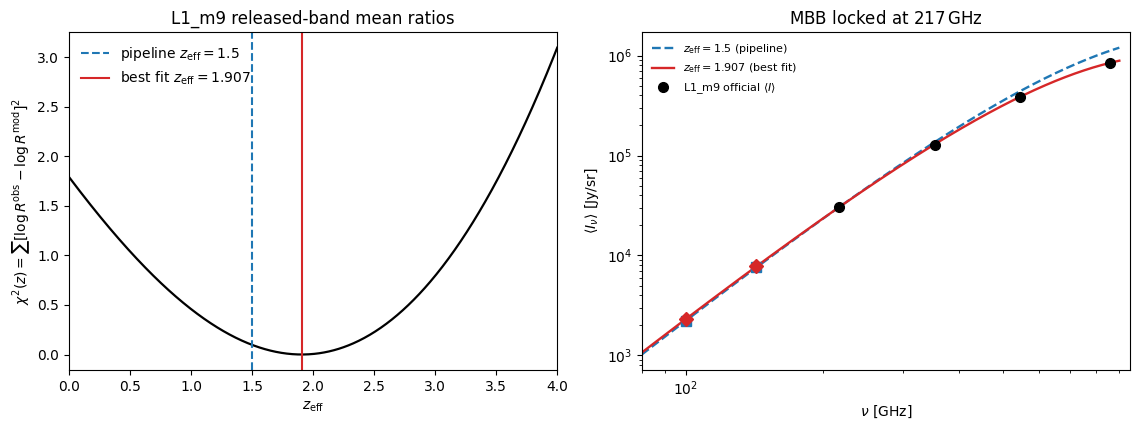

Interpretation:
  z_eff = 1.5 over-predicts 545 and 857 relative to 217
  (Wien side too hot). A larger z_eff cools T_obs = T0/(1+z) and
  matches the four official L1_m9 means. The shipped 100/143 GHz
  maps nevertheless use z_eff = 1.5 (see next section).


In [6]:
fig, axes = plt.subplots(1, 2, figsize=(11.5, 4.4))

ax = axes[0]
ax.plot(zs, chi2, "k-", lw=1.6)
ax.axvline(CIB_Z_EFF, color="C0", ls="--", lw=1.5, label=fr"pipeline $z_{{\rm eff}}={CIB_Z_EFF}$")
ax.axvline(z_best, color="C3", ls="-", lw=1.5, label=fr"best fit $z_{{\rm eff}}={z_best:.3f}$")
ax.set_xlabel(r"$z_{\mathrm{eff}}$")
ax.set_ylabel(r"$\chi^2(z)=\sum[\log R^{\mathrm{obs}}-\log R^{\mathrm{mod}}]^2$")
ax.set_title("L1_m9 released-band mean ratios")
ax.legend(frameon=False)
ax.set_xlim(0, 4)

ax = axes[1]
nu_grid = np.linspace(80, 900, 400)
for z, c, ls, lab in (
    (CIB_Z_EFF, "C0", "--", r"$z_{\mathrm{eff}}=1.5$ (pipeline)"),
    (z_best, "C3", "-", fr"$z_{{\rm eff}}={z_best:.3f}$ (best fit)"),
):
    # amplitude locked to 217
    sed = np.array([sed_ratio(nu, 217.0, z) for nu in nu_grid]) * means[217]
    ax.loglog(nu_grid, sed, color=c, ls=ls, lw=1.7, label=lab)

ax.loglog(
    RELEASED, [means[nu] for nu in RELEASED], "ko", ms=7, zorder=5, label=r"L1_m9 official $\langle I\rangle$"
)
# predicted 100/143 at both redshifts
for z, c, m in ((CIB_Z_EFF, "C0", "s"), (z_best, "C3", "D")):
    nus = (100.0, 143.0)
    I = [sed_ratio(nu, 217.0, z) * means[217] for nu in nus]
    ax.loglog(nus, I, m, color=c, ms=7, zorder=5)

ax.set_xlabel(r"$\nu$ [GHz]")
ax.set_ylabel(r"$\langle I_\nu\rangle$ [Jy/sr]")
ax.set_title(r"MBB locked at $217\,\mathrm{GHz}$")
ax.legend(frameon=False, fontsize=8)
ax.set_xlim(80, 950)
fig.tight_layout()
plt.show()

print("Interpretation:")
print("  z_eff = 1.5 over-predicts 545 and 857 relative to 217")
print("  (Wien side too hot). A larger z_eff cools T_obs = T0/(1+z) and")
print("  matches the four official L1_m9 means. The shipped 100/143 GHz")
print("  maps nevertheless use z_eff = 1.5 (see next section).")


## 4. Applying the scaling after $z_{\mathrm{eff}}=1.5$ (what is on disk)

The **fit** above is a diagnostic. The maps in `components/cib/L1_m9/` were built by
`scripts/build_l1_m9_fiducial_components.py` $\to$ `cib.make_cib_maps` with
`cfg.z_eff = CIB_Z_EFF = 1.5`.

Step by step, for $\nu\in\{100,143\}$:

**Step A — load the official $217\,\mathrm{GHz}$ intensity** (Jy/sr, $N_{\mathrm{side}}=4096$).

**Step B — scalar MBB ratio** (same number for every pixel):

$$
r(\nu,1.5)
=
\texttt{sed\_ratio}(\nu,\,217,\,z_{\mathrm{eff}}=1.5)
=
\frac{\Theta(\nu,1.5)}{\Theta(217,1.5)}.
$$

Numerically, with $(\beta_{\mathrm{d}},T_0,\alpha)=(1.65,\,35.14\,\mathrm{K},\,0)$:

$$
r(100,1.5)=0.073527,\qquad r(143,1.5)=0.250811.
$$

The FITS `METHOD` cards round these to `x0.074` and `x0.251`.

**Step C — apply to the map** (`cib.py`, the “outside released range” branch):

$$
I_\nu(\hat n)=r(\nu,1.5)\,I_{217}(\hat n).
$$

No extra spatial filtering, no bandpass integral, no pixel-dependent $z$. Small-scale
frequency decorrelation is neglected (acceptable: CIB is subdominant to CMB + noise at
$100/143\,\mathrm{GHz}$; Yang et al. Table 3).

**Step D — convert to $\mu\mathrm{K}_\mathrm{CMB}$:**

$$
\Delta T_\nu(\hat n)
=
\frac{I_\nu(\hat n)}{\mathrm{d}B_\nu/\mathrm{d}T\big|_{T_{\mathrm{CMB}}}}
\times 10^{6}.
$$

That is `intensity_to_uK(I, nu)` and is what `CIB_deltaT_{100,143}GHz_nside4096.fits` stores.

If one instead wanted the **best-fit** redshift from §3, the identical four steps apply
with $z_{\mathrm{eff}}=z_{\mathrm{best}}$; only the scalar $r(\nu,z)$ changes
($\sim 4\%$ at $100\,\mathrm{GHz}$ for L1_m9). The repo does **not** do that for the
shipped products.


In [7]:
print("Pipeline scalars at z_eff = 1.5  (and at z_best for comparison)\n")
print(f"{'nu':>6s}  {'r(z=1.5)':>12s}  {'r(z_best)':>12s}  {'delta %':>9s}  "
      f"{'dB/dT':>12s}  {'r_dT(1.5)':>12s}")
dBdT_217 = dB_dT_Jy_per_sr_per_K(217.0)
for nu in (100.0, 143.0, 217.0):
    r15 = sed_ratio(nu, 217.0, CIB_Z_EFF)
    rb = sed_ratio(nu, 217.0, z_best)
    dBdT = dB_dT_Jy_per_sr_per_K(nu)
    # DeltaT_nu / DeltaT_217 at z=1.5
    r_dt = r15 * dBdT_217 / dBdT
    print(
        f"{nu:6.0f}  {r15:12.6f}  {rb:12.6f}  {(rb/r15-1)*100:8.2f}%  "
        f"{dBdT:12.4e}  {r_dt:12.6f}"
    )

print("\nWorked example at 100 GHz, z_eff=1.5:")
r100 = sed_ratio(100.0, 217.0, 1.5)
print(f"  I_100(n)     = {r100:.6f} * I_217(n)          [Jy/sr]")
print(f"  dB/dT(100)   = {dB_dT_Jy_per_sr_per_K(100.0):.6e} Jy/sr/K")
print(f"  DeltaT_100   = I_100 / (dB/dT) * 1e6          [uK_CMB]")
print("  METHOD card  = 'SED scale from 217 GHz at z_eff=1.5 (x0.074)'")


Pipeline scalars at z_eff = 1.5  (and at z_best for comparison)

    nu      r(z=1.5)     r(z_best)    delta %         dB/dT     r_dT(1.5)
   100      0.073527      0.076436      3.96%    2.3879e+08      0.148921
   143      0.250811      0.257177      2.54%    3.7993e+08      0.319277
   217      1.000000      1.000000      0.00%    4.8364e+08      1.000000

Worked example at 100 GHz, z_eff=1.5:
  I_100(n)     = 0.073527 * I_217(n)          [Jy/sr]
  dB/dT(100)   = 2.387922e+08 Jy/sr/K
  DeltaT_100   = I_100 / (dB/dT) * 1e6          [uK_CMB]
  METHOD card  = 'SED scale from 217 GHz at z_eff=1.5 (x0.074)'


## 5. Reconstruct $100/143\,\mathrm{GHz}$ from $217\,\mathrm{GHz}$ and compare to disk

Call the same functions the pipeline uses, at $N_{\mathrm{side}}=64$, and compare to the
archived $\Delta T$ maps. Agreement at the $10^{-3}$ level (or better) confirms that the
on-disk $100/143$ files are exactly the $z_{\mathrm{eff}}=1.5$ scaling, not $z_{\mathrm{best}}$.


In [8]:
print("loading 217 GHz intensity (Jy/sr) ...", flush=True)
I217 = load_flamingo_map(CIB_DIR / "CIB_I_217GHz_nside4096.hdf5", nside_out=NSIDE_FIT)
cib_I = {217: I217}

for nu, ztag, z in (
    (100.0, "pipeline z=1.5", CIB_Z_EFF),
    (143.0, "pipeline z=1.5", CIB_Z_EFF),
):
    I, method = approximate_cib_intensity(nu, cib_I, z_eff=z)
    T_pred = intensity_to_uK(I, nu)
    T_disk = load_flamingo_map(
        CIB_DIR / f"CIB_deltaT_{int(nu)}GHz_nside4096.fits", nside_out=NSIDE_FIT
    )
    rel = (T_pred - T_disk) / np.mean(np.abs(T_disk))
    print(f"\n{int(nu)} GHz  [{ztag}]  {method}")
    print(f"  pred  mean={T_pred.mean():.6e} uK   std={T_pred.std():.6e}")
    print(f"  disk  mean={T_disk.mean():.6e} uK   std={T_disk.std():.6e}")
    print(f"  mean(pred/disk) = {np.mean(T_pred/T_disk):.8f}")
    print(f"  max |rel. residual| vs <|T_disk|> = {np.max(np.abs(rel)):.3e}")
    del I, T_pred, T_disk

# What 100 GHz would have been at z_best
I100_best, method_best = approximate_cib_intensity(100.0, cib_I, z_eff=z_best)
T100_best = intensity_to_uK(I100_best, 100.0)
T100_disk = load_flamingo_map(CIB_DIR / "CIB_deltaT_100GHz_nside4096.fits", nside_out=NSIDE_FIT)
print(f"\n100 GHz at z_best={z_best:.3f}: {method_best}")
print(
    f"  <T_best>/<T_disk> = {T100_best.mean()/T100_disk.mean():.4f}   "
    f"(~{(T100_best.mean()/T100_disk.mean()-1)*100:.2f}% hotter than shipped)"
)
del I217, cib_I, I100_best, T100_best, T100_disk


loading 217 GHz intensity (Jy/sr) ...



100 GHz  [pipeline z=1.5]  SED scale from 217 GHz at z_eff=1.5 (x0.074)
  pred  mean=9.302392e+00 uK   std=3.649452e-01
  disk  mean=9.302392e+00 uK   std=3.649452e-01
  mean(pred/disk) = 1.00000000
  max |rel. residual| vs <|T_disk|> = 1.756e-09



143 GHz  [pipeline z=1.5]  SED scale from 217 GHz at z_eff=1.5 (x0.251)
  pred  mean=1.994374e+01 uK   std=7.824194e-01
  disk  mean=1.994374e+01 uK   std=7.824194e-01
  mean(pred/disk) = 1.00000000
  max |rel. residual| vs <|T_disk|> = 1.716e-09



100 GHz at z_best=1.907: SED scale from 217 GHz at z_eff=1.9071513911855904 (x0.076)
  <T_best>/<T_disk> = 1.0396   (~3.96% hotter than shipped)


## 6. Summary

| Quantity | Value |
|---|---|
| Official CIB bands | $217,353,545,857\,\mathrm{GHz}$ (Jy/sr, Planck HFI bandpasses) |
| Dust model | $\beta_{\mathrm{d}}=1.65$, $T_0=35.14\,\mathrm{K}$, $\alpha=0$ |
| **Shipped** $100/143\,\mathrm{GHz}$ | $I_\nu=I_{217}\times\Theta(\nu,1.5)/\Theta(217,1.5)$, then $\mathrm{d}B_\nu/\mathrm{d}T$ |
| Scale factors at $z_{\mathrm{eff}}=1.5$ | $r_{100}=0.073527$, $r_{143}=0.250811$ |
| Best-fit $z_{\mathrm{eff}}$ to L1_m9 $\langle I\rangle$ | from the $\chi^2$ cell above ($\approx 1.9$) |
| Code | `spectral.sed_ratio`, `cib.approximate_cib_intensity`, `cib.make_cib_maps` |

To rebuild $100/143\,\mathrm{GHz}$ at a different $z_{\mathrm{eff}}$ one would pass
`MockConfig(z_eff=...)` into `cib.make_cib_maps`; this notebook does not write new maps.
